### Set up

In [1]:
# imports

from explore_import import  *
import ionbot_preprocess as io
import data_preprocess as dt
import tpp_preprocess as tpp
import hpp_checker as hpp

import pyteomics.auxiliary as aux
from pathlib import Path
import os, re, subprocess
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# base directories

root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
data_dir=f"{root}/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/fragpipe23_ms42/"
processed_dir=f"{root}/oui-discovery-vv-data/processed/msfragger_pride_reanalysis/fragpipe23_ms42/"
r_path="Rscript"
gwalk_work_dir=root
gwalk_script="Run_group_walk_tppfragpipe.R"

In [3]:
# replicate insides of data directory to preprocessed directory

#get insides of data directory
data_paths=dt.list_files(data_dir)

#replicate
for parent in data_paths.keys():
    new_parent=parent.replace(data_dir, processed_dir)
    os.makedirs(new_parent, exist_ok=True)

/
trembl/
    PXD014258/
        ESC_HF_SampleHela/
            psm.tsv
            peptide.tsv
            filelist_proteinprophet.txt
            filter.log
            interact.mod.pep.xml
            fragger.params
            log_2025-05-27_11-36-28.txt
            shepherd.config
            fragpipe.workflow
            ion.tsv
            combined.prot.xml
            sdrf.tsv
            interact.pep.xml
            fragpipe-files.fp-manifest
            ptm-shepherd-output/
                global.profile.tsv
                global.modsummary.tsv
        ESC_HF_Sample_BT474/
            interact.pep.xml
            log_2025-05-27_10-17-10.txt
            ion.tsv
            peptide.tsv
            filelist_proteinprophet.txt
            sdrf.tsv
            fragger.params
            psm.tsv
            combined.prot.xml
            interact.mod.pep.xml
            shepherd.config
            fragpipe.workflow
            filter.log
            fragpipe-files.fp-manifest
     

In [4]:
# modification variables

expected_mods={57.0215,15.9949, 42.0106}
expected_mods_name=['Iodoacetamide derivative/Addition of Glycine/Addition of G','Oxidation or Hydroxylation','Acetylation']
unmodified_threshold=0.01

### Load and process PeptideProphet files

In [5]:
def classify_leadprot(x):
    x=x.replace("decoy_","")
    if 'CONTAMINANT' in x.upper():
        return 'Contam'
    elif x.startswith('II_') or x.startswith('IP_'):
        return 'NonCanon'
        # Ensembl is canonical
    else:
        return 'Canon'

def is_peptide_canonical(x):
    '''x is the list of protein classes'''
    if np.array([_=='Contam' for _ in x]).any():
        return 'Contam'
    if np.array([_=='Canon' for _ in x]).any():
        return 'Canonical'
    return 'NonCanonical'

def custom_subgroup_filter(data_,key):
    filtered_subgroups = []
    for (c,m),df in data_.groupby(['isCanonical','isModified']).__iter__():
        tmp = aux.target_decoy.qvalues(df, key=key, reverse=True, is_decoy=df.database=='D',
                                      formula=1, full_output=True, q_label='custom_q')
        filtered_subgroups.append(tmp)

    return pd.concat(filtered_subgroups, ignore_index=True)

In [85]:
def annotate_massshift(value,ptm_df,col):
    #print(value)
    a=ptm_df[(ptm_df['peak_lower'] <= value) & (ptm_df['peak_upper'] >= value)]
    if len(a[col])==0 or a[col].isna().all(): 
        return None
    return "||".join(set([str(x).split("shift ")[-1] if "Unidentified" in str(x) or "Unannotated" in str(x) else str(x) for x in a[col].values.tolist()]))

In [86]:
def col_isna(df,col):
    return 100-round((df[col].isna().value_counts()[False]/len(data))*100,4)

In [186]:
data_paths

{'/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/fragpipe23_ms42/trembl/PXD014258/ESC_HF_SampleHela': ['psm.tsv',
  'peptide.tsv',
  'filelist_proteinprophet.txt',
  'filter.log',
  'interact.mod.pep.xml',
  'fragger.params',
  'log_2025-05-27_11-36-28.txt',
  'shepherd.config',
  'fragpipe.workflow',
  'ion.tsv',
  'combined.prot.xml',
  'sdrf.tsv',
  'interact.pep.xml',
  'fragpipe-files.fp-manifest'],
 '/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/fragpipe23_ms42/trembl/PXD014258/ESC_HF_SampleHela/ptm-shepherd-output': ['global.profile.tsv',
  'global.modsummary.tsv'],
 '/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/fragpipe23_ms42/trembl/PXD014258/ESC_HF_Sample_BT474': ['interact.pep.xml',
  'log_2025-05-27_10-17-10.txt',
  'ion.tsv',
  'peptide.tsv',


In [187]:
qval_score='peptideprophet_probability'

for parent, files in data_paths.items():
    new_parent=parent.replace(data_dir,processed_dir)
    database, dataset, spectrum_file = parent.split("/")[-3:]
    spectrum_file = spectrum_file.replace("_","-") if dataset=="PXD014258" else spectrum_file
    for file in files:
        if file.endswith(".mod.pep.xml"):
            # read PeptideProphet output
            pepxml_path=os.path.join(parent, file)
            data=pepxml.DataFrame(pepxml_path)
            print(f"{dataset}|{database}|{spectrum_file} N of discoveries: {len(data)}")

            #pin dataset and search_database
            data["dataset"] = dataset
            data["search_database"] = database
            data["spectrum_file"] = spectrum_file

            #pin T/D database
            data["database"]=data["protein"].apply(tpp.get_database_tpp)
            td_counts = round((data["database"].value_counts()/len(data))*100,4)
            print(f"{dataset}|{database}|{file} targets and decoys and NA: {td_counts['T']} and {td_counts['D']} and {col_isna(data,'database')}")

            #calculate global q-value on peptideprophet_probability
            print(f"{dataset}|{database}|{file} {qval_score} range and NA: {min(data[qval_score])} - {max(data[qval_score])} and {col_isna(data,qval_score)}")
            data = aux.target_decoy.qvalues(data,
                                            key=qval_score,
                                            reverse=True,
                                            is_decoy=(data.database == 'D'),
                                            q_label='global_q',
                                            formula=1,
                                            full_output=True)
            print(f"{dataset}|{database}|{file} 'global_q' range and NA: {min(data['global_q'])} - {max(data['global_q'])} and {col_isna(data,'global_q')}")

            #pin helpfull labels
            data["peptide_class"]=data["protein"].apply(tpp.classify_peptide_tpp)
            
            #pin subgroups
            data['protein_classes'] = data.protein.apply(lambda x: np.unique([classify_leadprot(_) for _ in x]))
            data['isCanonical'] = data.protein_classes.apply(is_peptide_canonical)
            
            #add modifications info
            ptmshepherd_file=os.path.join(parent, "ptm-shepherd-output", "global.profile.tsv")
            ptmshepherd_data = pd.read_csv(ptmshepherd_file, sep="\t")
            #correct columns read
            cols=ptmshepherd_data.columns.tolist()
            ptmshepherd_data=ptmshepherd_data.reset_index()
            ptmshepherd_data.columns=cols+["na"]
            #mass shift annotation
            data['massdiff']=data['massdiff'].astype(float)
            #data["mapped_mass_1"]=np.nan
            #data["mapped_mass_2"]=np.nan
            #data["mapped_mass_1"]=data["massdiff"].apply(lambda x: annotate_massshift(float(x) if isinstance(x,str) else x,ptmshepherd_data,"mapped_mass_1"))
            #data["mapped_mass_2"]=data["massdiff"].apply(lambda x: annotate_massshift(float(x) if isinstance(x,str) else x,ptmshepherd_data,"mapped_mass_2"))
            #data["n_apex"]=data["mapped_mass_1"].apply(lambda x: len(x.split("||")) if isinstance(x,str) else 0)
            ##reannotate variable modifications based on mapped_mass_1
            ##some mass shifts are not annotated by PTMShepherd (e.g. if low N of PSM) - mark them with unmodified_threshold
            #data["isModified"]=data.apply(lambda x: ("Unmodified" if abs(x["massdiff"])<=unmodified_threshold else "*Unexpected" ) if not isinstance(x["mapped_mass_1"],str) 
            #                                           else "Expected" if any([mod in x["mapped_mass_1"] for mod in expected_mods_name])
            #                                           else "Unexpected" ,axis=1)
            massdiffs={float(_):{"mapped_mass_1":[],"mapped_mass_2":[]} for _ in data.massdiff.unique()}
            for md in massdiffs.keys():
                sub=ptmshepherd_data[(ptmshepherd_data.peak_lower<=md)&(md<=ptmshepherd_data.peak_upper)]
                mapped_mass_1, mapped_mass_2 = sub.mapped_mass_1.tolist() , sub.mapped_mass_2.tolist()
                massdiffs[md]["mapped_mass_1"]= None if len(mapped_mass_1)==0 else "||".join([str(_) for _ in mapped_mass_1])
                massdiffs[md]["mapped_mass_2"]= None if len(mapped_mass_2)==0 else "||".join([str(_) for _ in mapped_mass_2])
            data=data.merge(pd.DataFrame(massdiffs).T.reset_index(), left_on="massdiff", right_on="index", how="left")
            data.loc[((data.mapped_mass_1.str.contains(expected_mods_name[0])) | (
            data.mapped_mass_1.str.contains(expected_mods_name[1])) | 
            (data.mapped_mass_1.str.contains(expected_mods_name[2]))) & (data.mapped_mass_2=='nan'),"isModified"]="Expected"
            data.loc[((data.mapped_mass_1=="nan")|(data.mapped_mass_1.isna()))&(abs(data.massdiff)<=unmodified_threshold),"isModified"]="Unmodified"
            data.loc[(data.isModified.isna()),"isModified"]="Unexpected"
            

            # Adds a columns telling you if a PSM passes the custom filters or not (custom_filter_pass)
            data = custom_subgroup_filter(data, qval_score)
            print(f"{dataset}|{database}|{file} 'custom_q' range and NA: {min(data['custom_q'])} - {max(data['custom_q'])} and {col_isna(data,'custom_q')}")
            #add hybrid/group-wise
            data["glob_cust_hybrid"]=data.apply(lambda x: x.custom_q if x.isCanonical=="NonCanonical" else x.global_q, axis=1)
            print(f"{dataset}|{database}|{file} 'glob_cust_hybrid' range and NA: {min(data['glob_cust_hybrid'])} - {max(data['glob_cust_hybrid'])} and {col_isna(data,'glob_cust_hybrid')}")
        
            # prepare for Group-walk
            data['isTarget'] = data.database.apply(lambda x: x=='T')
            data['FDRGroup'] = data.isCanonical + '_' + data.isModified
            fdrgroup_counts = round((data["FDRGroup"].value_counts()/len(data))*100,4)
            counts_str = ", ".join(
                f"{key} {fdrgroup_counts[key]}%"
                for key in list(fdrgroup_counts.keys())
            )
            na_count = col_isna(data, 'FDRGroup')
            print(f"{dataset}|{database}|{file} {counts_str}, NA {na_count}")
            #save for Group-walk
            #basename = os.path.basename(pepxml_path).split('.')[0]
            gwalk_input = os.path.join(new_parent, f"{spectrum_file}.csv")
            data.to_csv(gwalk_input,index=False)
            
            #run Group-walk
            dataset_dir = new_parent
            working_dir = gwalk_work_dir
            file_name = os.path.basename(gwalk_input)
            print(f"Run Group-walk on {gwalk_input}")
            command = (
                f"module load r && {r_path} {gwalk_script} {dataset_dir} {working_dir} {file_name}"
            )
            
            _ = subprocess.run(command, shell=True, check=True)
            
            qwalk_output = os.path.join(new_parent,"groupwalk_output_"+file_name)
            
            #add hybrid/group-walk
            data2=pd.read_csv(qwalk_output)
            data2['glob_group_hybrid']=data2.apply(lambda x: x.group_q_prob if x.isCanonical=="NonCanonical" else x.global_q, axis=1)
            print(f"{dataset}|{database}|{file} 'glob_group_hybrid' range and NA: {min(data2['glob_group_hybrid'])} - {max(data2['glob_group_hybrid'])} and {col_isna(data2,'glob_group_hybrid')}")
            data2.to_csv(qwalk_output,index=False)


#            break
#    break

PXD014258|trembl|ESC-HF-SampleHela N of discoveries: 30559
PXD014258|trembl|interact.mod.pep.xml targets and decoys and NA: 93.3538 and 6.6462 and 0.0
PXD014258|trembl|interact.mod.pep.xml peptideprophet_probability range and NA: 0.05 - 1.0 and 0.0
PXD014258|trembl|interact.mod.pep.xml 'global_q' range and NA: 0.0 - 0.0711932136848009 and 0.0
PXD014258|trembl|interact.mod.pep.xml 'custom_q' range and NA: 0.0 - 0.28505713013800266 and 0.0
PXD014258|trembl|interact.mod.pep.xml 'glob_cust_hybrid' range and NA: 0.0 - 0.0711932136848009 and 0.0
PXD014258|trembl|interact.mod.pep.xml Canonical_Unmodified 53.4409%, Canonical_Unexpected 28.3386%, Contam_Unexpected 9.7614%, Contam_Unmodified 7.173%, Canonical_Expected 0.7265%, Contam_Expected 0.5596%, NA 0.0
Run Group-walk on /project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/processed/msfragger_pride_reanalysis/fragpipe23_ms42/trembl/PXD014258/ESC_HF_SampleHela/ESC-HF-SampleHela.csv
PXD014258|trembl|int

/tmp/ipykernel_2451819/1979454044.py:111: DtypeWarning: Columns (44,45) have mixed types. Specify dtype option on import or set low_memory=False.
  data2=pd.read_csv(qwalk_output)


PXD014258|trembl|interact.mod.pep.xml 'glob_group_hybrid' range and NA: 0.0 - 0.0626703771013176 and 0.0
PXD014258|trembl|ESC-HF-Sample-MCF N of discoveries: 39337
PXD014258|trembl|interact.mod.pep.xml targets and decoys and NA: 94.1938 and 5.8062 and 0.0
PXD014258|trembl|interact.mod.pep.xml peptideprophet_probability range and NA: 0.05 - 1.0 and 0.0
PXD014258|trembl|interact.mod.pep.xml 'global_q' range and NA: 0.0 - 0.06164143254257415 and 0.0
PXD014258|trembl|interact.mod.pep.xml 'custom_q' range and NA: 0.0 - 0.21032431395125695 and 0.0
PXD014258|trembl|interact.mod.pep.xml 'glob_cust_hybrid' range and NA: 0.0 - 0.06164143254257415 and 0.0
PXD014258|trembl|interact.mod.pep.xml Canonical_Unmodified 52.279%, Canonical_Unexpected 32.0665%, Contam_Unexpected 7.901%, Contam_Unmodified 5.9435%, Canonical_Expected 1.1923%, Contam_Expected 0.6177%, NA 0.0
Run Group-walk on /project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/processed/msfragger_prid

/tmp/ipykernel_2451819/1979454044.py:111: DtypeWarning: Columns (44,45) have mixed types. Specify dtype option on import or set low_memory=False.
  data2=pd.read_csv(qwalk_output)


PXD014258|trembl|interact.mod.pep.xml 'glob_group_hybrid' range and NA: 0.0 - 0.0616414325425741 and 0.0
PXD002057|trembl|130327_o2_02_hu_P1_2hr N of discoveries: 9854
PXD002057|trembl|interact-130327_o2_02_hu_P1_2hr.mod.pep.xml targets and decoys and NA: 94.7534 and 5.2466 and 0.0
PXD002057|trembl|interact-130327_o2_02_hu_P1_2hr.mod.pep.xml peptideprophet_probability range and NA: 0.0501 - 1.0 and 0.0
PXD002057|trembl|interact-130327_o2_02_hu_P1_2hr.mod.pep.xml 'global_q' range and NA: 0.0 - 0.055371104209060724 and 0.0
PXD002057|trembl|interact-130327_o2_02_hu_P1_2hr.mod.pep.xml 'custom_q' range and NA: 0.0 - 0.13576333861595352 and 0.0
PXD002057|trembl|interact-130327_o2_02_hu_P1_2hr.mod.pep.xml 'glob_cust_hybrid' range and NA: 0.0 - 0.055371104209060724 and 0.0
PXD002057|trembl|interact-130327_o2_02_hu_P1_2hr.mod.pep.xml Canonical_Unmodified 44.6824%, Canonical_Unexpected 43.6371%, Canonical_Expected 7.2965%, Contam_Unexpected 2.5573%, Contam_Unmodified 1.2076%, Contam_Expected 0.6

...

PXD005833|openprot|interact-AM17.mod.pep.xml 'custom_q' range and NA: 0.0 - inf and 0.0
PXD005833|openprot|interact-AM17.mod.pep.xml 'glob_cust_hybrid' range and NA: 0.0 - inf and 0.0
PXD005833|openprot|interact-AM17.mod.pep.xml Canonical_Unexpected 42.7359%, Canonical_Unmodified 41.7723%, NonCanonical_Unexpected 6.4732%, Contam_Unexpected 4.1374%, Contam_Unmodified 2.9433%, Canonical_Expected 1.8435%, Contam_Expected 0.0524%, NonCanonical_Unmodified 0.0314%, NonCanonical_Expected 0.0105%, NA 0.0
Run Group-walk on /project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/processed/msfragger_pride_reanalysis/fragpipe23_ms42/openprot/PXD005833/AM17/AM17.csv
PXD005833|openprot|interact-AM17.mod.pep.xml 'glob_group_hybrid' range and NA: 0.0 - 0.0361367335865437 and 0.0
PXD005833|openprot|AM10 N of discoveries: 10680
PXD005833|openprot|interact-AM10.mod.pep.xml targets and decoys and NA: 96.8258 and 3.1742 and 0.0
PXD005833|openprot|interact-AM10.mod.pep.x

/tmp/ipykernel_2451819/1979454044.py:111: DtypeWarning: Columns (44,45) have mixed types. Specify dtype option on import or set low_memory=False.
  data2=pd.read_csv(qwalk_output)


PXD014258|canon|interact.mod.pep.xml 'glob_group_hybrid' range and NA: 0.0 - 0.0315917671416393 and 0.0
PXD014258|canon|ESC-HF-Sample-BT474 N of discoveries: 40292
PXD014258|canon|interact.mod.pep.xml targets and decoys and NA: 96.5998 and 3.4002 and 0.0
PXD014258|canon|interact.mod.pep.xml peptideprophet_probability range and NA: 0.05 - 1.0 and 0.0
PXD014258|canon|interact.mod.pep.xml 'global_q' range and NA: 0.0 - 0.03519860233287087 and 0.0
PXD014258|canon|interact.mod.pep.xml 'custom_q' range and NA: 0.0 - 0.1165821868211441 and 0.0
PXD014258|canon|interact.mod.pep.xml 'glob_cust_hybrid' range and NA: 0.0 - 0.03519860233287087 and 0.0
PXD014258|canon|interact.mod.pep.xml Canonical_Unmodified 55.6339%, Canonical_Unexpected 30.6165%, Contam_Unexpected 6.3908%, Contam_Unmodified 4.8918%, Canonical_Expected 1.8813%, Contam_Expected 0.5857%, NA 0.0
Run Group-walk on /project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/processed/msfragger_pride_rea

/tmp/ipykernel_2451819/1979454044.py:111: DtypeWarning: Columns (44,45) have mixed types. Specify dtype option on import or set low_memory=False.
  data2=pd.read_csv(qwalk_output)


PXD014258|canon|interact.mod.pep.xml 'glob_group_hybrid' range and NA: 0.0 - 0.0351986023328709 and 0.0


In [152]:
massdiffs={float(_):{"mapped_mass_1":[],"mapped_mass_2":[]} for _ in data.massdiff.unique()}
for md in massdiffs.keys():
    sub=ptmshepherd_data[(ptmshepherd_data.peak_lower<=md)&(md<=ptmshepherd_data.peak_upper)]
    mapped_mass_1, mapped_mass_2 = sub.mapped_mass_1.tolist() , sub.mapped_mass_2.tolist()
    massdiffs[md]["mapped_mass_1"]= None if len(mapped_mass_1)==0 else "||".join([str(_) for _ in mapped_mass_1])
    massdiffs[md]["mapped_mass_2"]= None if len(mapped_mass_2)==0 else "||".join([str(_) for _ in mapped_mass_2])
data_2=data.merge(pd.DataFrame(massdiffs).T.reset_index(), left_on="massdiff", right_on="index", how="left")
data_2.loc[((data_2.mapped_mass_1_y.str.contains(expected_mods_name[0])) | (
data_2.mapped_mass_1_y.str.contains(expected_mods_name[1])) | 
(data_2.mapped_mass_1_y.str.contains(expected_mods_name[2]))) & (data_2.mapped_mass_2_y=='nan'),"isModified_2"]="Expected"
data_2.loc[((data_2.mapped_mass_1_y=="nan")|(data_2.mapped_mass_1_y.isna()))&(abs(data_2.massdiff)<=unmodified_threshold),"isModified_2"]="Unmodified"
data_2.loc[(data_2.isModified_2.isna()),"isModified_2"]="Unexpected"
data_2["FDRGroup_2"]= data_2.isCanonical + data_2.isModified_2

(-1.0, 1.0)

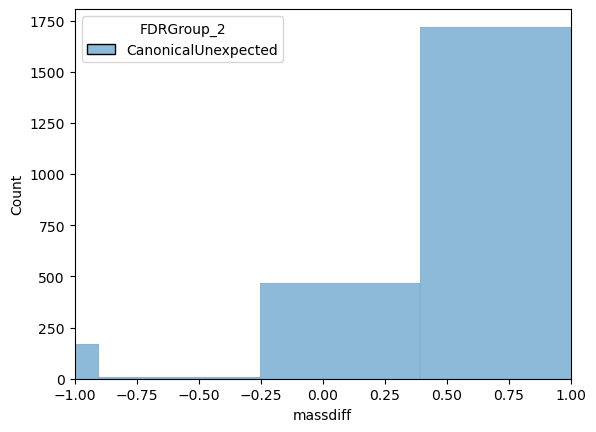

In [168]:
sns.histplot(data=data_2[data_2.FDRGroup_2=="CanonicalUnexpected"] , x="massdiff", hue="FDRGroup_2",bins=1000)#, cut=0)
plt.xlim(-1,1)

<Axes: xlabel='massdiff'>

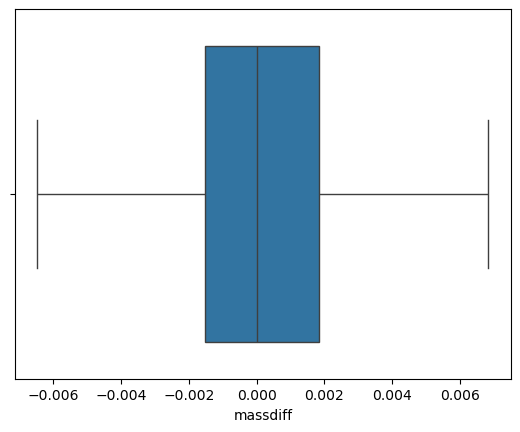

In [179]:
sns.boxplot(data_2[((data_2.mapped_mass_1_y=="nan")|(data_2.mapped_mass_1_y.isna()))],x="massdiff", showfliers=False)
#plt.xlim(-0.05,0.05)

<Axes: xlabel='massdiff', ylabel='Density'>

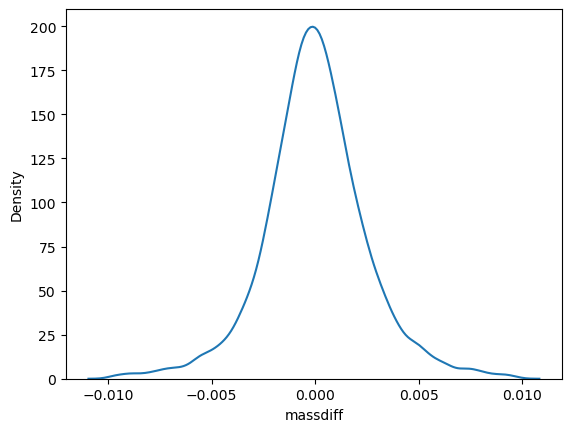

In [147]:
sns.kdeplot(
data_2[((data_2.mapped_mass_1_y=="nan")|(data_2.mapped_mass_1_y.isna()))&(abs(data_2.massdiff)<=unmodified_threshold)]
    , x="massdiff")

<Axes: xlabel='massdiff', ylabel='Density'>

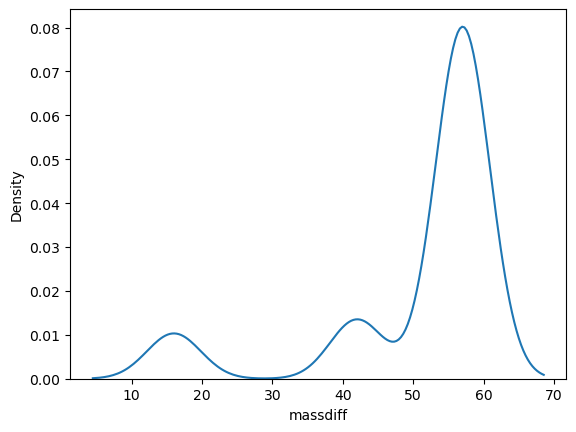

In [142]:
sns.kdeplot(
data_2[((data_2.mapped_mass_1_y.str.contains(expected_mods_name[0])) | (
data_2.mapped_mass_1_y.str.contains(expected_mods_name[1])) | 
(data_2.mapped_mass_1_y.str.contains(expected_mods_name[2]))) & (data_2.mapped_mass_2_y=='nan')
], x="massdiff")